# My Pandas Advanced Practice Notebook

This is my own re-build of the *Pandas Advanced Practice* notebook. I follow the same six topics, but I
rewrote the code, asked my own questions of the data, and added improvements along the way.

| # | Topic | What I use it for |
|---|-------|-------------------|
| 1 | Group & aggregate | Per-group questions (fare by class, survival by sex) |
| 2 | Concatenate & merge | Stacking tables and joining them on a key |
| 3 | Clean: missing values, duplicates, binning | Getting data ready before analysis |
| 4 | Pivot & crosstab | Reshaping long data into readable grids |
| 5 | Visualisation | Turning tables into charts |
| 6 | Time series | Dates, resampling, shifting and rolling windows |

**My improvements** are marked with ⭐ in the headings. Summary:
1. ⭐ Explore and **handle missing data** (fill `age` with a group-aware median instead of ignoring it).
2. ⭐ **Named aggregations** and a **survival-rate** analysis — a more meaningful question than average fare.
3. ⭐ A **reusable function** that compares all four merge types in one call (with `indicator=True`).
4. ⭐ **`pd.qcut` vs `pd.cut`** — testing a different binning strategy.
5. ⭐ New plots: **heatmaps**, a **grouped bar chart**, and a **boxplot by group**.
6. ⭐ Time series: a **reproducible seed**, **seasonal** synthetic data, **daily returns** with `pct_change`, and **testing different rolling-window sizes**.

Run with `Shift + Enter`, top to bottom. Works in Google Colab with no setup.

## 0. Setup

In [1]:
import pandas as pd                 # tables (DataFrames)
import numpy as np                  # numeric helpers and random numbers
import matplotlib.pyplot as plt     # the plotting engine pandas uses under the hood
import seaborn as sns               # practice datasets + nicer plot styles

sns.set_style("whitegrid")          # light grid background for every chart
pd.set_option("display.precision", 2)   # show 2 decimals so tables are easier to read

print("pandas version:", pd.__version__)

pandas version: 3.0.2


In [2]:
# Titanic: one row per passenger (891 rows)
titanic = sns.load_dataset("titanic")
print(titanic.shape)
titanic.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.25,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.28,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.92,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.10,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.05,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Before analysing, I always check column types and how much is missing
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


## 1. ⭐ Improvement: Handling Missing Data

The original notebook never looked at missing values, but `age` is missing for about 20% of passengers.
That silently affects later results (e.g. `pd.cut` puts missing ages in no bin at all).
So first I measure the problem, then decide what to do column by column.

In [4]:
# Count and percentage of missing values per column (only columns that have any)
missing = titanic.isna().sum()
missing_pct = (missing / len(titanic) * 100).round(1)
missing_report = pd.DataFrame({"missing": missing, "percent": missing_pct})
missing_report[missing_report["missing"] > 0].sort_values("missing", ascending=False)

,missing,percent
deck,688,77.2
age,177,19.9
embarked,2,0.2
embark_town,2,0.2


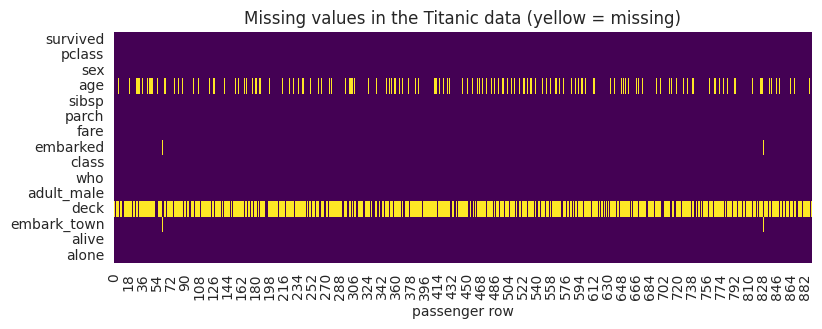

In [5]:
# Visualise the gaps: each yellow line is a missing value
plt.figure(figsize=(9, 3))
sns.heatmap(titanic.isna().T, cbar=False, cmap="viridis", yticklabels=True)
plt.title("Missing values in the Titanic data (yellow = missing)")
plt.xlabel("passenger row")
plt.show()

**My decisions:**
- `deck` is ~77% missing → too empty to fill honestly, so I drop it.
- `embarked` / `embark_town` have only 2 missing → fill with the most common port (the mode).
- `age` is ~20% missing → instead of one overall average, I fill each gap with the **median age of passengers with the same class and sex**.
  First-class passengers were older on average than third-class ones, so this is more realistic.
  I keep a flag column `age_was_missing` so I can always tell which ages are estimates.

In [6]:
# Work on a copy so the raw data stays untouched
clean = titanic.drop(columns=["deck"]).copy()

# Fill the 2 missing ports with the most frequent value
for col in ["embarked", "embark_town"]:
    clean[col] = clean[col].fillna(clean[col].mode()[0])

# Group-aware fill for age: median age within each (class, sex) group
clean["age_was_missing"] = clean["age"].isna()
group_median_age = clean.groupby(["class", "sex"], observed=True)["age"].transform("median")
clean["age"] = clean["age"].fillna(group_median_age)

print("missing values left:", clean.isna().sum().sum())
clean.groupby(["class", "sex"], observed=True)["age"].median().unstack()   # the medians used

missing values left: 0


sex,female,male
class,,
First,35.0,40.0
Second,28.0,30.0
Third,21.5,25.0


## 2. Group & Aggregate

`groupby` splits the table into groups, applies a calculation to each, and combines the results
("split → apply → combine").

In [7]:
# How many passengers in each class?
class_groups = clean.groupby("class", observed=True)
class_groups.size()

class
First     216
Second    184
Third     491
dtype: int64

In [8]:
# Oldest passenger in each class (using the *original* ages, so no estimates sneak in)
titanic.groupby("class", observed=True)["age"].max()

class
First     80.0
Second    70.0
Third     74.0
Name: age, dtype: float64

In [9]:
# Several statistics on fare at once
class_groups["fare"].agg(["count", "min", "median", "mean", "max"])

,count,min,median,mean,max
class,,,,,
First,216,0.0,60.29,84.15,512.33
Second,184,0.0,14.25,20.66,73.50
Third,491,0.0,8.05,13.68,69.55


### ⭐ Improvement: named aggregations

Instead of a list of function names, **named aggregation** lets me compute different statistics on
different columns *and* give each result a readable name — all in one step.

In [10]:
class_summary = clean.groupby("class", observed=True).agg(
    passengers   = ("survived", "size"),
    survival_rate= ("survived", "mean"),   # mean of a 0/1 column = proportion who survived
    median_age   = ("age", "median"),
    avg_fare     = ("fare", "mean"),
)
class_summary

,passengers,survival_rate,median_age,avg_fare
class,,,,
First,216,0.63,38.0,84.15
Second,184,0.47,30.0,20.66
Third,491,0.24,25.0,13.68


In [11]:
# Group by two columns: survival rate for every (class, sex) combination
survival_by_class_sex = clean.groupby(["class", "sex"], observed=True)["survived"].mean()
survival_by_class_sex

class   sex   
First   female    0.97
        male      0.37
Second  female    0.92
        male      0.16
Third   female    0.50
        male      0.14
Name: survived, dtype: float64

In [12]:
# .unstack() moves the inner level (sex) into columns, which is much easier to read
survival_by_class_sex.unstack().round(2)

sex,female,male
class,,
First,0.97,0.37
Second,0.92,0.16
Third,0.50,0.14


**What this shows:** women in first and second class survived at over 90%, while men in second and third class
survived at under 20%. Sex mattered even more than class.

## 3. Concatenate & Merge

- **Concatenate** (`pd.concat`) = glue tables together along an axis (usually stacking rows).
- **Merge** (`df.merge`) = line up rows from two tables that share a key, like a SQL JOIN.

In [13]:
# Split into one table per embarkation town (instead of class, to try something different)
southampton = clean[clean["embark_town"] == "Southampton"]
cherbourg   = clean[clean["embark_town"] == "Cherbourg"]
print("Southampton:", southampton.shape, "| Cherbourg:", cherbourg.shape)

# Stack them; ignore_index gives a fresh 0..n-1 index
both_ports = pd.concat([southampton, cherbourg], ignore_index=True)
print("Combined:   ", both_ports.shape)

# Sanity check: rows add up
assert len(both_ports) == len(southampton) + len(cherbourg)

Southampton: (646, 15) | Cherbourg: (168, 15)
Combined:    (814, 15)


In [14]:
# keys= labels where each row came from (creates a two-level index)
pd.concat([southampton.head(2), cherbourg.head(2)], keys=["S", "C"])[["embark_town", "class", "fare"]]

embark_town   class   fare
S 0  Southampton   Third   7.25
  2  Southampton   Third   7.92
C 1    Cherbourg   First  71.28
  9    Cherbourg  Second  30.07

In [15]:
# Two small tables that share the 'student' key
exam_scores = pd.DataFrame({
    "student": ["Ava", "Ben", "Chloe", "Dev"],
    "score":   [88, 92, 67, 75],
})
club_members = pd.DataFrame({
    "student": ["Chloe", "Dev", "Eli", "Fay"],
    "club":    ["Robotics", "Chess", "Drama", "Robotics"],
})
display(exam_scores, club_members)

,student,score
0,Ava,88
1,Ben,92
2,Chloe,67
3,Dev,75


,student,club
0,Chloe,Robotics
1,Dev,Chess
2,Eli,Drama
3,Fay,Robotics


### ⭐ Improvement: a function that compares merge types

Rather than writing four nearly identical cells, I wrote one function. `indicator=True` adds a `_merge`
column that says whether each row came from the left table, the right table, or both — which makes the
differences between join types obvious.

In [16]:
def compare_merges(left, right, key):
    """Run inner, left, right and outer merges and print each result with its row count."""
    for how in ["inner", "left", "right", "outer"]:
        result = left.merge(right, on=key, how=how, indicator=True)
        print(f"--- {how.upper()} join: {len(result)} rows ---")
        print(result.to_string(index=False), end="\n\n")

compare_merges(exam_scores, club_members, key="student")

--- INNER join: 2 rows ---
student  score     club _merge
  Chloe     67 Robotics   both
    Dev     75    Chess   both

--- LEFT join: 4 rows ---
student  score     club    _merge
    Ava     88      NaN left_only
    Ben     92      NaN left_only
  Chloe     67 Robotics      both
    Dev     75    Chess      both

--- RIGHT join: 4 rows ---
student  score     club     _merge
  Chloe   67.0 Robotics       both
    Dev   75.0    Chess       both
    Eli    NaN    Drama right_only
    Fay    NaN Robotics right_only

--- OUTER join: 6 rows ---
student  score     club     _merge
    Ava   88.0      NaN  left_only
    Ben   92.0      NaN  left_only
  Chloe   67.0 Robotics       both
    Dev   75.0    Chess       both
    Eli    NaN    Drama right_only
    Fay    NaN Robotics right_only



- **inner** → only Chloe and Dev (in both tables)
- **left** → every student with a score; Ava and Ben get `NaN` for club
- **right** → every club member; Eli and Fay get `NaN` for score
- **outer** → everyone from both tables

## 4. Removing Duplicates & Binning

In [17]:
# A small table with one exact duplicate row (Ben twice) and a repeated score (92)
attendance = pd.DataFrame({
    "student": ["Ava", "Ben", "Ben", "Chloe", "Dev"],
    "score":   [88, 92, 92, 67, 92],
})
print("duplicated rows:", attendance.duplicated().sum())
attendance

duplicated rows: 1


,student,score
0,Ava,88
1,Ben,92
2,Ben,92
3,Chloe,67
4,Dev,92


In [18]:
# Drop exact duplicate rows (keeps the first copy by default)
attendance.drop_duplicates()

,student,score
0,Ava,88
1,Ben,92
3,Chloe,67
4,Dev,92


In [19]:
# Duplicates judged on one column only; keep='last' keeps the last occurrence instead
attendance.drop_duplicates(subset=["score"], keep="last")

,student,score
0,Ava,88
3,Chloe,67
4,Dev,92


In [20]:
# Does the real Titanic data contain exact duplicates?
print("exact duplicate rows in titanic:", titanic.duplicated().sum())

exact duplicate rows in titanic: 107


Interesting: the Titanic data has over 100 "duplicate" rows. They aren't really the same person —
the dataset has no passenger name or ID, so different passengers with identical attributes look the same.
**Lesson:** only drop duplicates when rows truly represent the same record, so I leave them in.

In [21]:
# BINNING with pd.cut: I choose the bucket edges myself
age_bins   = [0, 12, 18, 35, 60, 100]
age_labels = ["child", "teen", "young adult", "adult", "senior"]
clean["age_group"] = pd.cut(clean["age"], bins=age_bins, labels=age_labels)

clean["age_group"].value_counts().sort_index()

age_group
child           69
teen            70
young adult    514
adult          216
senior          22
Name: count, dtype: int64

### ⭐ Improvement: testing a different binning method — `pd.qcut`

`pd.cut` uses **fixed edges**, so groups can be very uneven in size. `pd.qcut` uses **quantiles**,
so every bin gets (roughly) the same number of passengers. That's useful for fare, which is extremely skewed.

In [22]:
fare_cut  = pd.cut(clean["fare"], bins=4)                                    # 4 equal-width bins
fare_qcut = pd.qcut(clean["fare"], q=4, labels=["Q1 low", "Q2", "Q3", "Q4 high"])   # 4 equal-count bins

print("pd.cut  (equal width):\n", fare_cut.value_counts().sort_index(), "\n")
print("pd.qcut (equal count):\n", fare_qcut.value_counts().sort_index())

pd.cut  (equal width):
 fare
(-0.512, 128.082]     853
(128.082, 256.165]     29
(256.165, 384.247]      6
(384.247, 512.329]      3
Name: count, dtype: int64 

pd.qcut (equal count):
 fare
Q1 low     223
Q2         224
Q3         222
Q4 high    222
Name: count, dtype: int64


In [23]:
# Using the quartiles: does paying more relate to surviving?
clean["fare_quartile"] = fare_qcut
clean.groupby("fare_quartile", observed=True)["survived"].mean().round(2)

fare_quartile
Q1 low     0.20
Q2         0.30
Q3         0.45
Q4 high    0.58
Name: survived, dtype: float64

## 5. Pivot Table & Crosstab

- `pivot_table` = long data → wide summary grid, with an aggregation function (mean by default).
- `crosstab` = counts (or proportions) for every combination of two categories.

In [24]:
flights = sns.load_dataset("flights")   # monthly airline passengers, 1949–1960
print(flights.shape)
flights.head()

(144, 3)


,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [25]:
# Months down the side, years across the top, passengers in the cells
flights_grid = flights.pivot_table(index="month", columns="year", values="passengers",
                                   aggfunc="sum", observed=True)
flights_grid

year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112,115,145,171,196,204,242,284,315,340,360,417
Feb,118,126,150,180,196,188,233,277,301,318,342,391
Mar,132,141,178,193,236,235,267,317,356,362,406,419
Apr,129,135,163,181,235,227,269,313,348,348,396,461
May,121,125,172,183,229,234,270,318,355,363,420,472
Jun,135,149,178,218,243,264,315,374,422,435,472,535
Jul,148,170,199,230,264,302,364,413,465,491,548,622
Aug,148,170,199,242,272,293,347,405,467,505,559,606
Sep,136,158,184,209,237,259,312,355,404,404,463,508


In [26]:
# pivot_table with margins: survival rate by class × age group, plus overall 'All' row/column
clean.pivot_table(index="class", columns="age_group", values="survived",
                  aggfunc="mean", margins=True, observed=True).round(2)

age_group,child,teen,young adult,adult,senior,All
class,,,,,,
First,0.75,0.92,0.79,0.54,0.21,0.63
Second,1.00,0.50,0.43,0.38,0.33,0.47
Third,0.42,0.28,0.24,0.09,0.20,0.24
All,0.58,0.43,0.36,0.38,0.23,0.38


In [27]:
# crosstab: counts of each class × sex combination, with totals
pd.crosstab(clean["class"], clean["sex"], margins=True)

sex,female,male,All
class,,,
First,94,122,216
Second,76,108,184
Third,144,347,491
All,314,577,891


In [28]:
# normalize='index' turns counts into row percentages — share of each class that survived
pd.crosstab(clean["class"], clean["survived"], normalize="index").round(2)

survived,0,1
class,,
First,0.37,0.63
Second,0.53,0.47
Third,0.76,0.24


## 6. Visualisation

Pandas has `.plot()` built in (it calls Matplotlib). I reproduce each chart type from the original
and then add a few new ones.

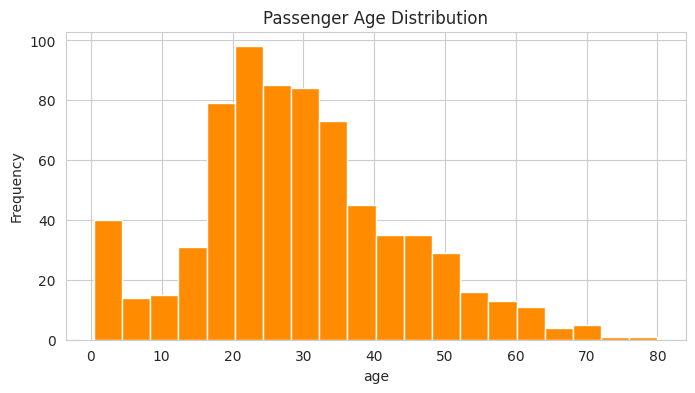

In [29]:
# HISTOGRAM — distribution of one numeric column (original ages only, no filled values)
titanic["age"].plot.hist(bins=20, color="darkorange", edgecolor="white", figsize=(8, 4),
                         title="Passenger Age Distribution")
plt.xlabel("age")
plt.show()

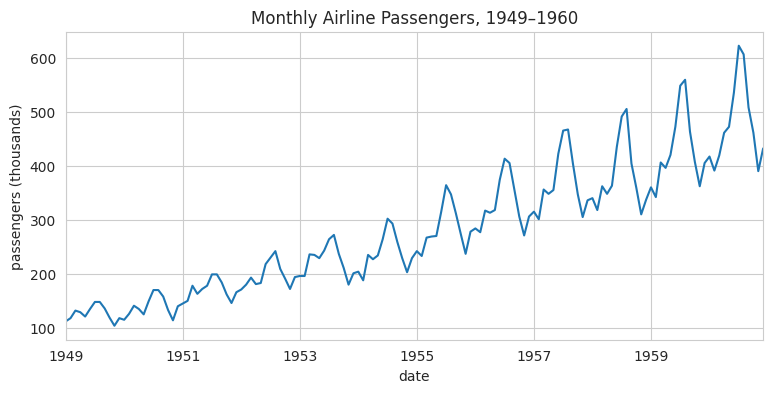

In [30]:
# LINE plot — the original plotted against the row number; I build a real date so the x-axis is time
flights["date"] = pd.to_datetime(flights["year"].astype(str) + "-" + flights["month"].astype(str),
                                 format="%Y-%b")
flights.plot.line(x="date", y="passengers", figsize=(9, 4), legend=False,
                  title="Monthly Airline Passengers, 1949–1960")
plt.ylabel("passengers (thousands)")
plt.show()

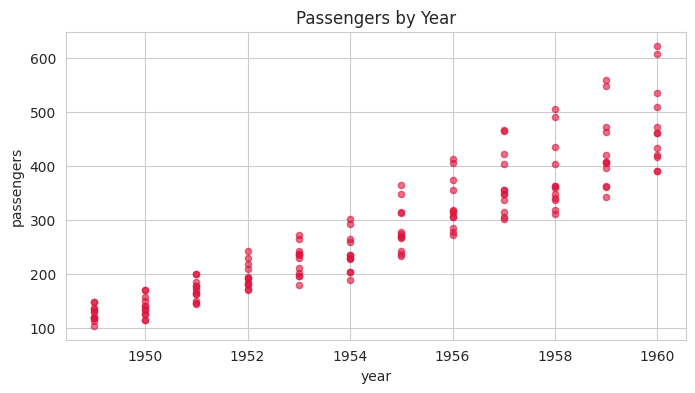

In [31]:
# SCATTER — each dot is one month; shows growth and widening spread over the years
flights.plot.scatter(x="year", y="passengers", color="crimson", alpha=0.6, figsize=(8, 4),
                     title="Passengers by Year")
plt.show()

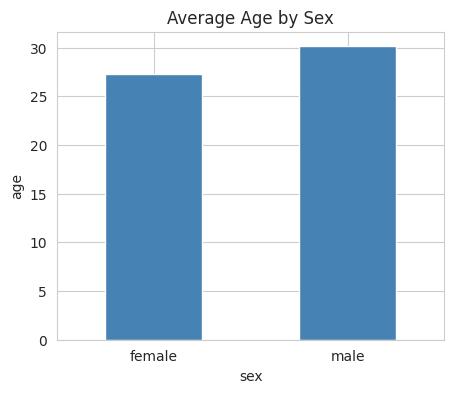

In [32]:
# BAR — average age by sex
clean.groupby("sex", observed=True)["age"].mean().plot.bar(
    color="steelblue", rot=0, figsize=(5, 4), title="Average Age by Sex")
plt.ylabel("age")
plt.show()

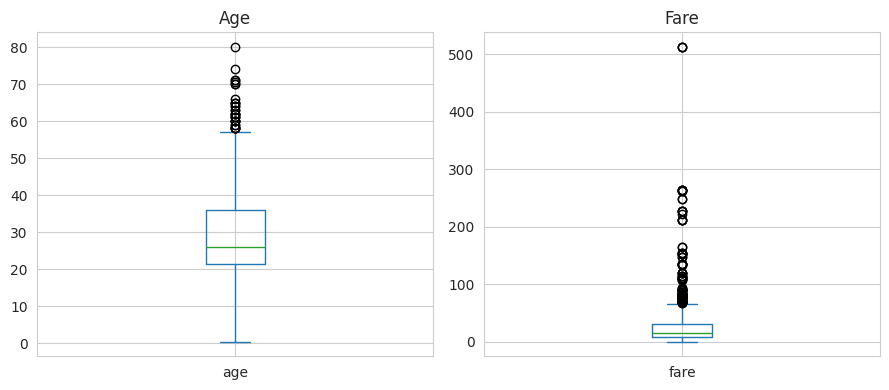

In [33]:
# BOX — the original put age and fare in one plot, but fare's scale squashed age.
# I use two side-by-side panels so each has its own y-axis.
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
clean["age"].plot.box(ax=axes[0], title="Age")
clean["fare"].plot.box(ax=axes[1], title="Fare")
plt.tight_layout()
plt.show()

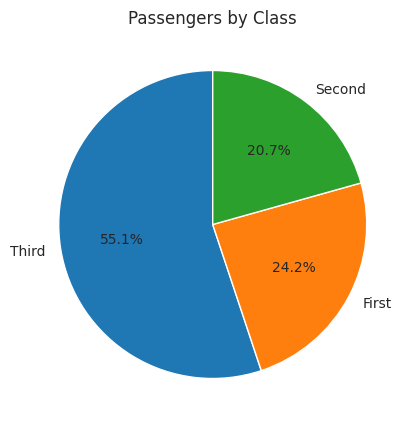

In [34]:
# PIE — share of passengers in each class
clean["class"].value_counts().plot.pie(autopct="%1.1f%%", figsize=(5, 5),
                                       title="Passengers by Class", startangle=90)
plt.ylabel("")
plt.show()

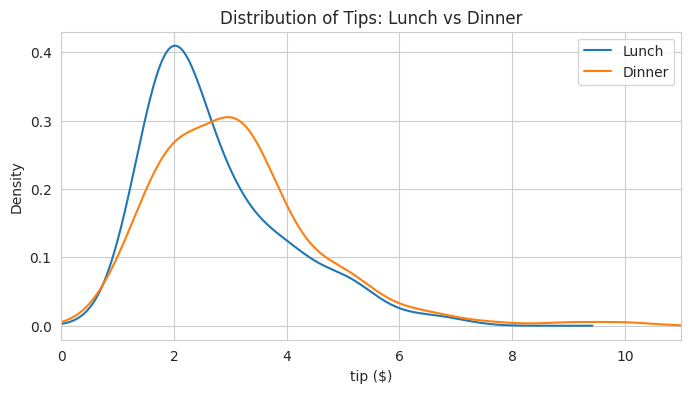

In [35]:
# KDE — smooth distribution of tips, comparing lunch vs dinner (original showed only one curve)
tips = sns.load_dataset("tips")
fig, ax = plt.subplots(figsize=(8, 4))
for when, group in tips.groupby("time", observed=True):
    group["tip"].plot.kde(ax=ax, label=when)
ax.set_xlim(0, 11)
ax.set_title("Distribution of Tips: Lunch vs Dinner")
ax.set_xlabel("tip ($)")
ax.legend()
plt.show()

### ⭐ Improvement: new plots

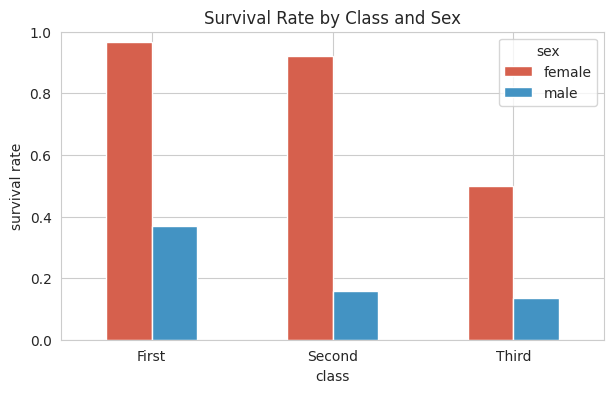

In [36]:
# GROUPED BAR — survival rate by class, split by sex (the unstacked table from section 2)
survival_by_class_sex.unstack().plot.bar(rot=0, figsize=(7, 4), color=["#d6604d", "#4393c3"],
                                         title="Survival Rate by Class and Sex")
plt.ylabel("survival rate")
plt.ylim(0, 1)
plt.show()

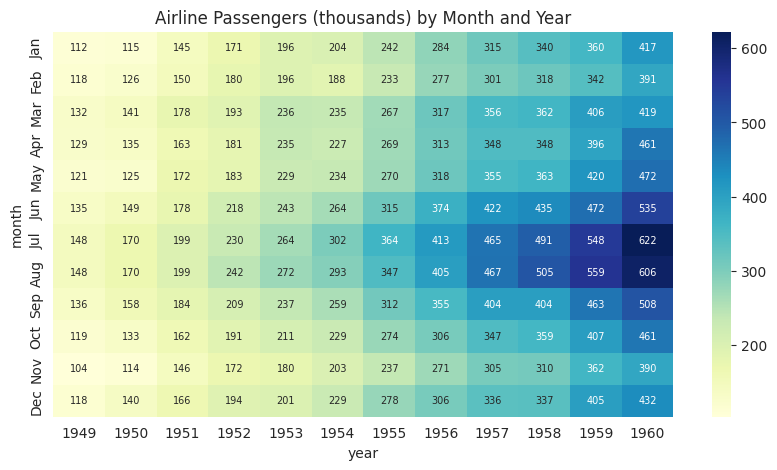

In [37]:
# HEATMAP of the flights pivot table — seasonality and growth jump out at once
plt.figure(figsize=(10, 5))
sns.heatmap(flights_grid, cmap="YlGnBu", annot=True, fmt="d", annot_kws={"size": 7})
plt.title("Airline Passengers (thousands) by Month and Year")
plt.show()

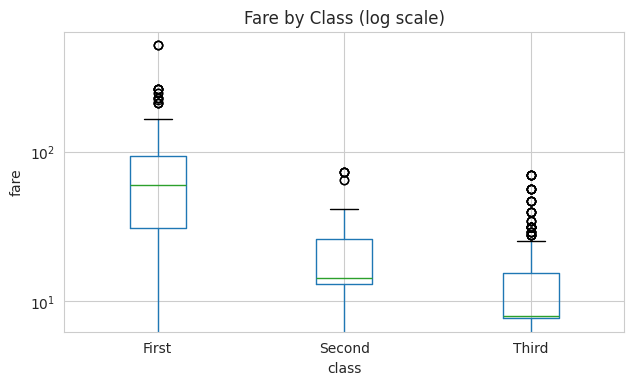

In [38]:
# BOX plot BY GROUP — fare spread in each class (log scale because a few fares are huge)
ax = clean.boxplot(column="fare", by="class", figsize=(7, 4))
ax.set_yscale("log")
ax.set_title("Fare by Class (log scale)")
plt.suptitle("")
plt.ylabel("fare")
plt.show()

## 7. Time Series

A time series is a sequence of values indexed by time. Pandas makes dates first-class: you can create
ranges, change frequency (resample), look back in time (shift) and smooth (rolling windows).

In [39]:
# Every day of the first half of 2021
days = pd.date_range(start="2021-01-01", end="2021-06-30", freq="D")
print(len(days), "days, from", days.min().date(), "to", days.max().date())

181 days, from 2021-01-01 to 2021-06-30


### ⭐ Improvement: reproducible, realistic synthetic data

The original used pure random numbers, so every run gave different results and the chart was just noise.
I set a **random seed** (same numbers every run) and add a **seasonal warming trend** plus noise,
so the data actually behaves like temperatures.

In [40]:
rng = np.random.default_rng(seed=42)                        # reproducible random generator
trend = np.linspace(5, 28, len(days))                        # winter → summer warming (°C)
noise = rng.normal(loc=0, scale=3, size=len(days))           # day-to-day variation
weather = pd.DataFrame({"temperature": (trend + noise).round(1)}, index=days)
weather.index.name = "date"
weather.head()

,temperature
date,
2021-01-01,5.9
2021-01-02,2.0
2021-01-03,7.5
2021-01-04,8.2
2021-01-05,-0.3


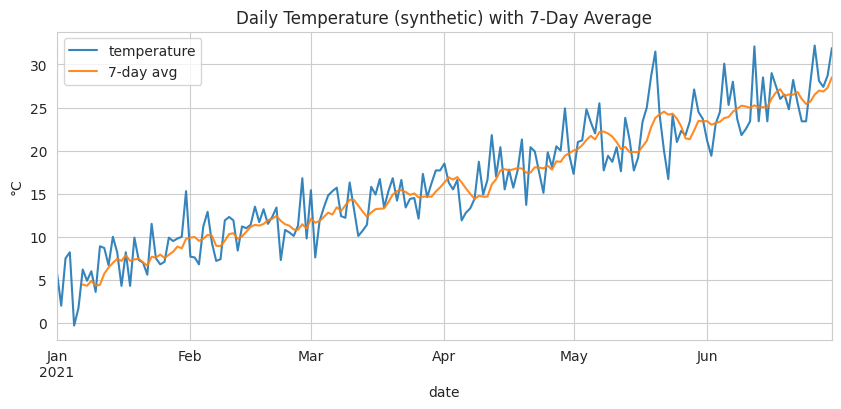

In [41]:
# Daily values plus a 7-day rolling mean to see the trend through the noise
weather["7-day avg"] = weather["temperature"].rolling(7).mean()
weather.plot(figsize=(10, 4), title="Daily Temperature (synthetic) with 7-Day Average",
             style=["-", "-"], alpha=0.9)
plt.ylabel("°C")
plt.show()

In [42]:
# Resample daily → monthly average ('ME' = month end)
weather["temperature"].resample("ME").mean().round(1)

date
2021-01-31     7.2
2021-02-28    10.7
2021-03-31    14.3
2021-04-30    17.5
2021-05-31    22.2
2021-06-30    26.0
Freq: ME, Name: temperature, dtype: float64

### Real data: Google stock prices (2004–2022)

In [43]:
url = ("https://raw.githubusercontent.com/duochen/data-science-bootcamp/"
       "refs/heads/main/Data/google_stock_prices.csv")

# parse_dates + index_col do the date conversion and indexing in one step
stock = pd.read_csv(url, parse_dates=["Date"], index_col="Date")
print(stock.shape, "| from", stock.index.min().date(), "to", stock.index.max().date())
stock.head()

(4431, 6) | from 2004-08-19 to 2022-03-24


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2004-08-19,50.05,52.08,48.03,50.22,50.22,44659096
2004-08-20,50.56,54.59,50.30,54.21,54.21,22834343
2004-08-23,55.43,56.80,54.58,54.75,54.75,18256126
2004-08-24,55.68,55.86,51.84,52.49,52.49,15247337
2004-08-25,52.53,54.05,51.99,53.05,53.05,9188602


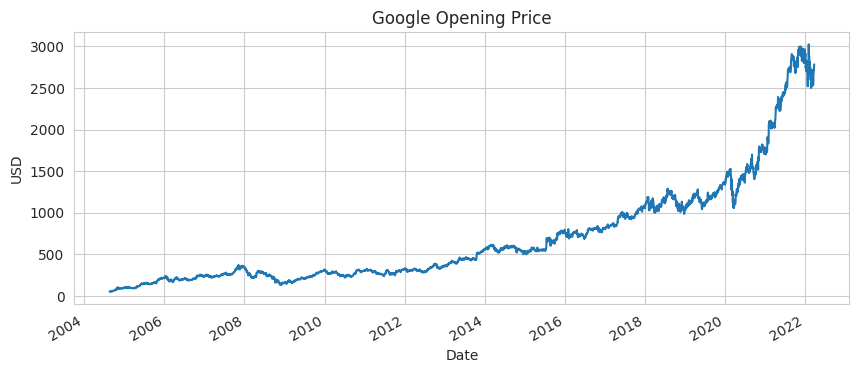

In [44]:
stock["Open"].plot(figsize=(10, 4), title="Google Opening Price")
plt.ylabel("USD")
plt.show()

In [45]:
# Resample to yearly: average open, plus first/last price of each year with named aggregation
yearly = stock["Open"].resample("YE").agg(avg="mean", first="first", last="last")
yearly.index = yearly.index.year          # show '2005' instead of '2005-12-31'
yearly.round(1)

,avg,first,last
Date,,,
2004,75.8,50.1,99.7
2005,139.0,98.8,208.8
2006,206.2,211.5,231.3
2007,269.7,233.2,349.6
2008,233.4,346.8,152.3
2009,219.7,154.5,312.7
2010,268.4,313.8,298.7
2011,284.9,298.5,321.3
2012,321.7,326.8,350.4


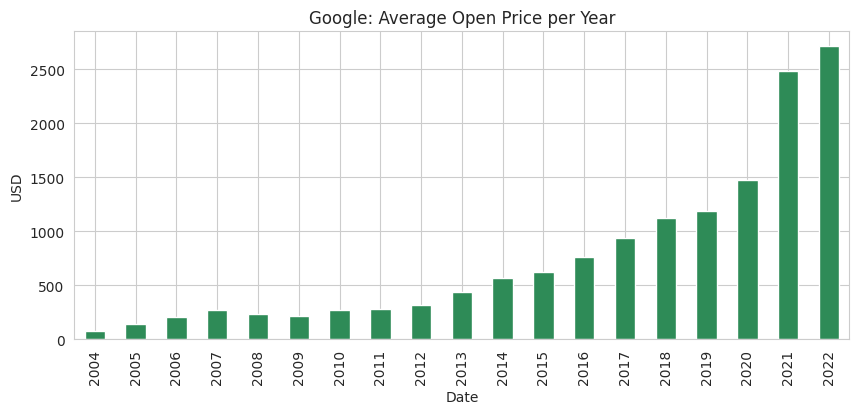

In [46]:
yearly["avg"].plot.bar(figsize=(10, 4), color="seagreen", title="Google: Average Open Price per Year")
plt.ylabel("USD")
plt.show()

In [47]:
# SHIFT: put yesterday's open next to today's
stock["prev_open"] = stock["Open"].shift(1)
stock[["Open", "prev_open"]].head()

,Open,prev_open
Date,,
2004-08-19,50.05,NaN
2004-08-20,50.56,50.05
2004-08-23,55.43,50.56
2004-08-24,55.68,55.43
2004-08-25,52.53,55.68


### ⭐ Improvement: daily returns

Raw price changes aren't comparable across years ($1 means a lot more in 2004 than in 2021).
A **percentage change** fixes that. `pct_change()` is the same as `(today − yesterday) / yesterday`,
which I verify using the shifted column.

In [48]:
stock["daily_return"] = stock["Close"].pct_change()

# Check pct_change against the manual formula built with shift
manual = (stock["Close"] - stock["Close"].shift(1)) / stock["Close"].shift(1)
print("pct_change matches manual shift formula:", np.allclose(stock["daily_return"], manual, equal_nan=True))

# Biggest single-day moves
stock["daily_return"].agg(["mean", "std", "min", "max"]).round(4)

pct_change matches manual shift formula: True


mean    1.10e-03
std     1.91e-02
min    -1.16e-01
max     2.00e-01
Name: daily_return, dtype: float64

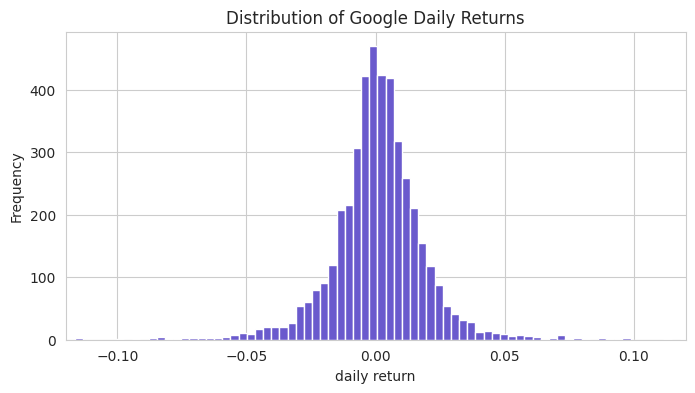

In [49]:
stock["daily_return"].plot.hist(bins=100, figsize=(8, 4), color="slateblue",
                                title="Distribution of Google Daily Returns")
plt.xlabel("daily return")
plt.xlim(-0.12, 0.12)
plt.show()

### ⭐ Improvement: testing different rolling-window sizes

The original used one 30-day window. Here I compare **30 vs 200 days** on a recent period so the lines are readable.
A short window reacts quickly but is noisy; a long window is smooth but lags behind the price.

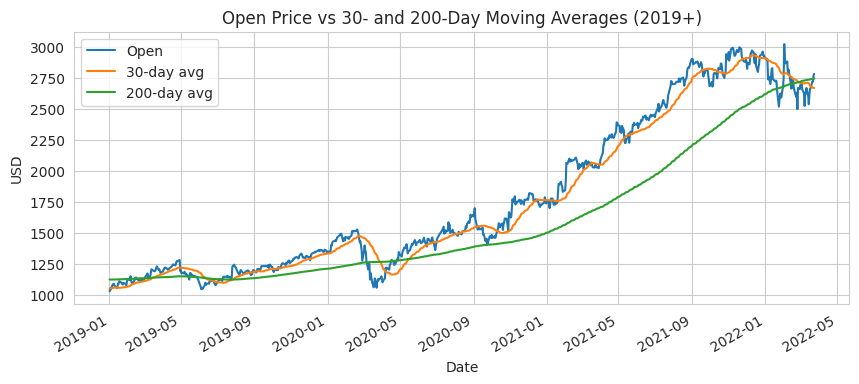

In [50]:
for window in [30, 200]:
    stock[f"{window}-day avg"] = stock["Open"].rolling(window=window).mean()

recent = stock.loc["2019":, ["Open", "30-day avg", "200-day avg"]]
recent.plot(figsize=(10, 4), title="Open Price vs 30- and 200-Day Moving Averages (2019+)")
plt.ylabel("USD")
plt.show()

In [51]:
# How many NaNs does each window create at the start? (window - 1 rows have too little history)
stock[["30-day avg", "200-day avg"]].isna().sum()

30-day avg      29
200-day avg    199
dtype: int64

## Reflection

This notebook was about the Pandas skills that come up in almost every real data-science project:
summarising by group, combining tables, cleaning, reshaping, plotting, and working with dates.
I rebuilt it from scratch using the same flow, but I tried to ask real questions of the data,
like who survived the Titanic, instead of only demonstrating each function.
My biggest change was adding a missing-data step at the start, where I filled missing ages with the median
for each class and sex instead of ignoring them, and kept a flag column so estimates stay visible.
I also used named aggregations, wrote a reusable function that compares all four merge types, compared
`pd.cut` with `pd.qcut`, added heatmaps and grouped bar charts, and in the time-series section I added a random seed,
daily returns with `pct_change`, and a comparison of 30- vs 200-day rolling windows.
One thing that surprised me was that the Titanic data has over 100 "duplicate" rows that are really different
passengers, which taught me not to call `drop_duplicates()` without thinking about what a row represents.
I learned that `groupby` + `unstack` is one of the fastest ways to turn a question into a readable table,
and that the choice of parameters (bin edges, window size, join type) can change the story the data tells.
Overall, I feel much more confident cleaning and reshaping data before I start drawing conclusions from it.